<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بهتر ببینیم
</font>
</h1>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مقدمه
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین با تصاویر ایکس ری و عکس از سطح شهر کار خواهیم کرد. این تصاویر بصورت خام و بدون هیچگونه پردازشی در اختیار شما قرار گرفته اند. هدف شما این است که با انجام پردازشهای مناسب، کیفیت این تصاویر را بهبود بخشید و آنها را برای تحلیلهای بعدی آماده کنید.
</font>
</p>

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بخش اول: بهبود روشنایی
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش یکی از کاربردهای مهم پردازش تصویر را بررسی می‌کنیم: بهبود تصاویر پزشکی.
به‌ویژه در تصویربرداری  ایکس‌ری، افزایش روشنایی و کنتراست می‌تواند به نمایش بهتر جزئیات کمک کند.
در این تمرین، با استفاده از تکنیک‌های پردازش تصویر، روی یک تصویر اولیه پیش‌پردازش انجام می‌دهیم تا ویژگی‌های آن واضح‌تر شوند.
</font>
</p>


<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله اول
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
ابتدا تصویر را بارگزاری کنید. دقت کنید که حتما تصویر را به شکل خاکستری بارگزاری کنید.
</font>
</p>

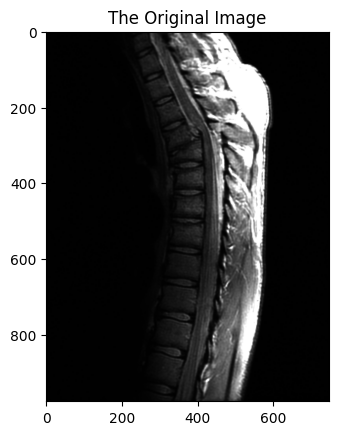

In [11]:
original_image = cv2.imread("Data/Fractured Spine.tif", cv2.IMREAD_GRAYSCALE)
plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
plt.title("The Original Image")
plt.show()

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
    مرحله دوم
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این مرحله، قصد داریم روشنایی پیکسل‌هایی را که مقدار شدت روشنایی آن‌ها بین 10 تا 50 است، افزایش دهیم.
هر پیکسلی که در این بازه قرار داشته باشد، 40 واحد روشن‌تر خواهد شد تا جزئیات تصویر بهتر دیده شوند.
همچنین بیشترین شدت برابر 255 است. نباید هیچ پیکسلی در تصویر دارای روشنایی بیشتر از 255 باشد.
</font>
</p>


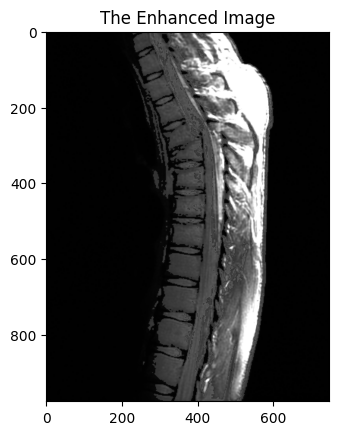

In [12]:
range_start, range_end = 10, 50
height, width = original_image.shape
image = original_image

for r in range(height):
    for c in range(width):
        if (image[r, c] >= range_start) and (image[r, c] <= range_end):
            image[r, c] += 40
        image[r, c] = 255 if image[r, c] > 255 else image[r, c]


plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("The Enhanced Image")
plt.show()

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله سوم
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
حال در این مرحله تصویر بهبود یافته را ذخیره کنید. دقت کنید که حتما تصویر را از حوزه خاسکتری به حوزه RGB انتقال دهید و سپس تصویر را ذخیره کنید.
نام تصویر ذخیره شده باید Enhanced_Fractured_Spine.tif باشد.
</font>
</p>

In [13]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2.imwrite('Enhanced_Fractured_Spine.tif', image)

True

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بخش دوم: تبدیل نمایی
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین قصد داریم تا تبدیل نمایی را به دو شکل متفاوت بررسی کنیم. ما در این تمرین تبدیل نمایی را به شکل زیر مدل می‌کنیم.
$$ I_{\text{transformed}} = I^{\gamma} $$

دقت کنید که در پیاده‌سازی خود شما نیز تبدیل نمایی را به شکل فرمول بالا حتما مدل کنید.

ما تبدیل نمایی را بر روی دو تصویر ایکس ری و تصویر سطح شهر بررسی خواهیم کرد.
</font>
</p>


---

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله اول: خواندن تصویر سطح شهر
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در ابتدا تصویر سطح شهر را با شکل خاکستری بخوانید.
    نام فایل: Aerial Image.tif
</font>
</p>

In [14]:
aerial_image = cv2.imread('Data/Aerial Image.tif', cv2.IMREAD_GRAYSCALE)

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله دوم: اعمال تبدیل نمایی
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش تبدیل نمایی را بر روی تمام پیکسل‌های تصویر باید اعمال کنیم. پارامترهای این تبدیل به شما داده خواهد شد.
    <br>
    قبل از اعمال تبدیل بر روی هر پیسکل، پیشنهاد می‌کنیم که ابتدا مقدار آن پیکسل را نرمال کنید. برای نرمال کردن هر پیکسل از فرمول زیر استفاده کنید:
    
$$I_{\text{norm}} = \frac{I - I_{\min}}{I_{\max} - I_{\min}}$$
</font>
</p>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
        دقت کنید که پس این مرحله روشنایی تمام پیکسل‌ها در بازه $[0, 1]$ قرا خواهد گرفت.
    ما این فرمول را روی تمام پیکسل‌های تصویر اعمال می‌کنیم. ازآنجا که کمترین شدن روشنایی  برابر 0 است و بیشترین شدت 255 است، فرمول نهایی نرمال‌سازی به شکل زیر است:
    
$$I_{\text{norm}} = \frac{I - 0}{255 - 0}$$
    
</font>
</p>


<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
پس از اینکه هر پیسکل نرمال شد، باید تبدیل را روی آن اعمال کنیم. دقت کنید که پس از اعمال تبدیل، مقدار حاصل شده را در 255 باید ضرب کنید. این ضرب باعث میشود تا مقدار پیکسل‌ها دوباره به بازه $[0, 255]$ بازگردد.
</font>
</p>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
فرمول نهایی تبدیل به شرح زیر است:
    $$ I_{\text{transformed}} = 255 * (I^{\gamma}) $$
</font>
</p>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    در این بخش می‌خواهیم تبدیل نمایی را با ${\gamma} > 1$ مشاهده کنیم.
شما باید به ازای ${\gamma}$ زیر نتابج این تبدیل را بررسی کنید.
$${\gamma} = 1$$
$${\gamma} = 3 $$
$${\gamma} = 4 $$
$${\gamma} = 5 $$
</font>
</p>


In [15]:
def power_law_transformation(image, gamma):
    transformed_image = image.copy()
    height, width = image.shape

    for r in range(height):
        for c in range(width):
            pixel = float(image[r, c]) / 255.0
            transformed_image[r, c] = (pixel ** gamma) * 255

    return np.uint8(transformed_image)

all_gamma = [1, 3, 4, 5]
enhanced_image = []
for gamma in all_gamma:
    enhanced_image.append(power_law_transformation(aerial_image, gamma))

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله سوم: ذخیره تصاویر بهبود یافته سطح شهر
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این مرحله هر 4 تصویر را به ترتیب به نام‌های زیر در پوشه تمرین ذخیره کنید:
<br>
new_aerial_gamma_1.tif
<br>
new_aerial_gamma_3.tif
<br>
new_aerial_gamma_4.tif
<br>
new_aerial_gamma_5.tif
</font>
</p>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
دقت کنید که حتما تصاویر را به حوزه RGB منتقل کنید و سپس آنها را ذخیره کنید.
</font>
</p>

In [16]:
for i, image in enumerate(enhanced_image):
    cv2.imwrite(f'new_aerial_{all_gamma[i]}.tif', cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

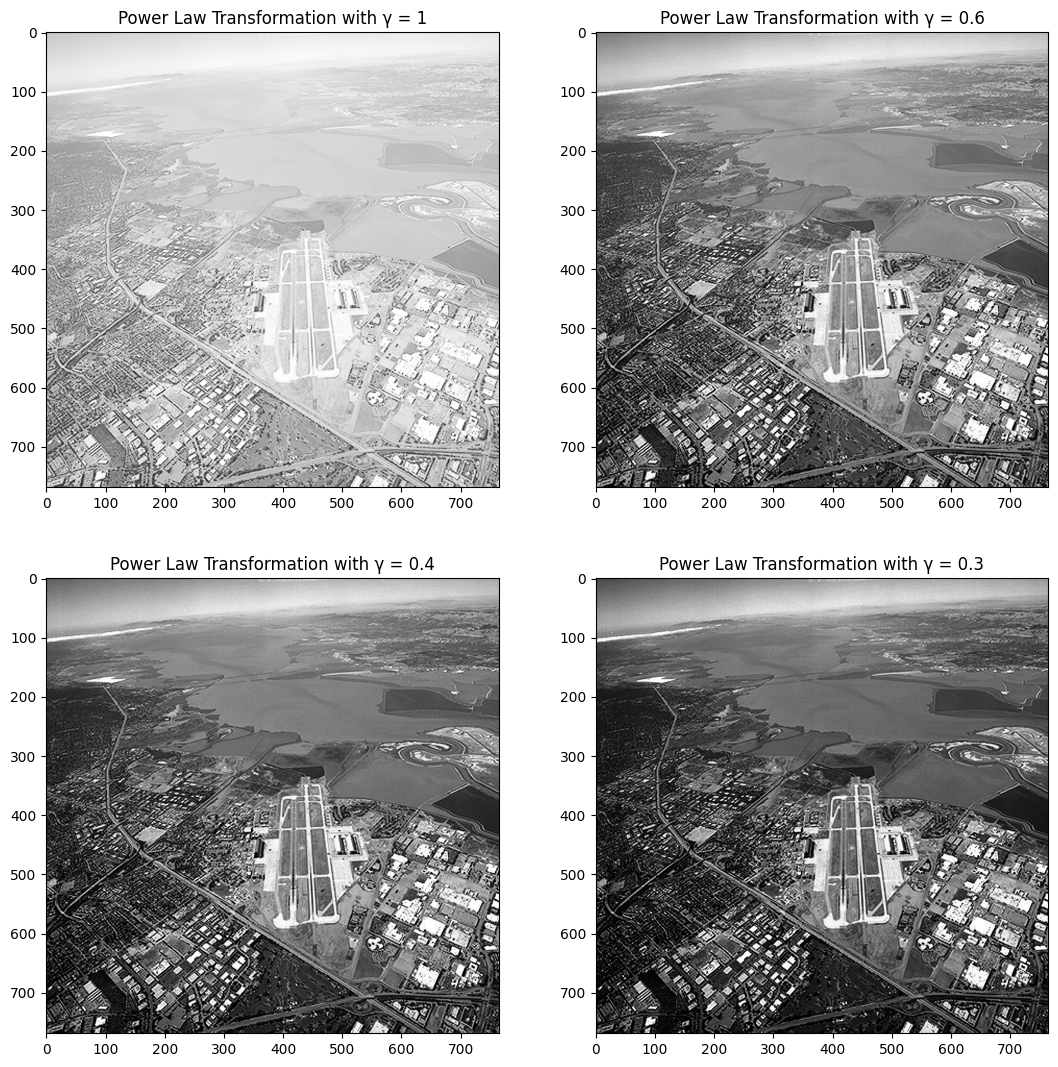

In [26]:
plt.figure(figsize = (13, 13))

for i, image in enumerate(enhanced_image):
    plt.subplot(2, 2, i+1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"Power Law Transformation with γ = {all_gamma[i]}")

plt.show()

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله چهارم: تبدیل نمایی بر تصاویر ایکس‌ری
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    تمام مراحلی که در بخش قبل بر روی تصویر سطح شهر انجام دادیم، حال می‌خواهیم بر روی تصویر x-ray نیز انجام دهیم.
</font>
</p>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    تصویر Fractured Spine.tif را بصورت خاکستری وارد کنید.
</font>
</p>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش می‌خواهیم تبدیل نمایی را با ${\gamma} < 1$ مشاهده کنیم.
شما باید به ازای ${\gamma}$ زیر نتابج این تبدیل را بررسی کنید.
$${\gamma} = 1 $$
$${\gamma} = 0.6 $$
$${\gamma} = 0.4 $$
$${\gamma} = 0.3 $$
</font>
</p>


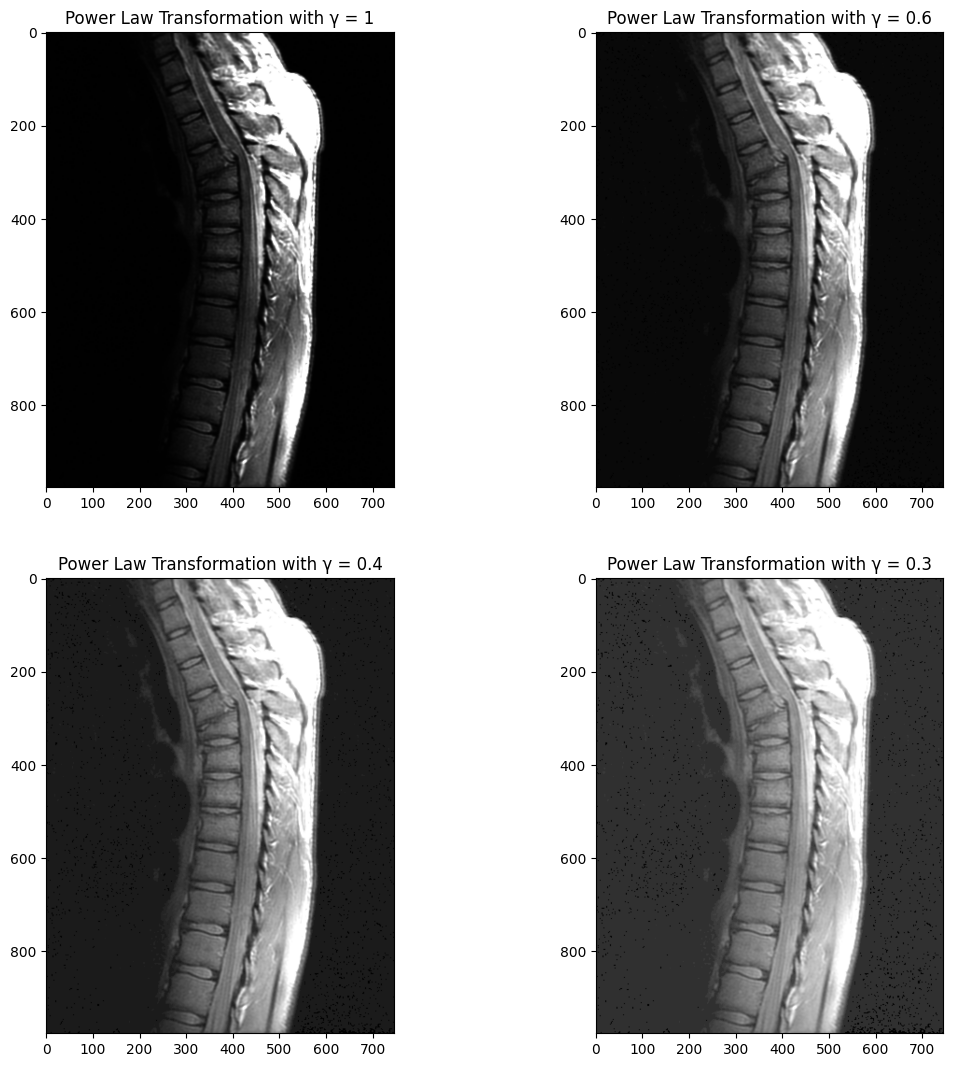

In [18]:
spine_image = cv2.imread("Data/Fractured Spine.tif", cv2.IMREAD_GRAYSCALE)

all_gamma = [1, 0.6, 0.4, 0.3]
xray_enhanced_image = []
for gamma in all_gamma:
    xray_enhanced_image.append(power_law_transformation(spine_image, gamma))

plt.figure(figsize = (13, 13))

for i, image in enumerate(xray_enhanced_image):
    plt.subplot(2, 2, i+1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"Power Law Transformation with γ = {all_gamma[i]}")

plt.show()

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله پنجم: ذخیره تصاویر بهبود یافته ایکس ری
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این مرحله هر 4 تصویر را به ترتیب به نام‌های زیر در پوشه تمرین ذخیره کنید:
<br>
Fractured_Spine_gamma_1.tif
<br>
Fractured_Spine_gamma_0.6.tif
<br>
Fractured_Spine_gamma_0.4.tif
<br>
Fractured_Spine_gamma_0.3.tif
</font>
</p>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
دقت کنید که حتما تصاویر را به حوزه RGB منتقل کنید و سپس آنها را ذخیره کنید.
</font>
</p>

In [19]:
for i, gamma in enumerate(all_gamma):
    cv2.imwrite(f'Fractured_Spine_gamma_{gamma}.tif', cv2.cvtColor(xray_enhanced_image[i], cv2.COLOR_BGR2RGB))

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله ششم: سلول جواب‌ساز
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
بدون هیچگونه تغییری، این سلول را اجرا کنید تا فایل پاسخ شما آماده شود.
</font>
</p>

In [20]:
import zipfile

def compress(file_names):
    print("File Paths:")
    print(file_names)
    # Select the compression mode ZIP_DEFLATED for compression
    # or zipfile.ZIP_STORED to just store the file
    compression = zipfile.ZIP_DEFLATED
    # create the zip file first parameter path/name, second mode
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            # Add file to the zip file
            # first parameter file to zip, second filename in zip
            zf.write('./' + file_name, file_name, compress_type=compression)


file_names = ["notebook.ipynb", "Enhanced_Fractured_Spine.tif", "Fractured_Spine_gamma_0.3.tif", "Fractured_Spine_gamma_0.4.tif",
              "Fractured_Spine_gamma_0.6.tif", "Fractured_Spine_gamma_1.tif", "new_aerial_1.tif",
              "new_aerial_3.tif", "new_aerial_4.tif", "new_aerial_5.tif"]
compress(file_names)

File Paths:
['notebook.ipynb', 'Enhanced_Fractured_Spine.tif', 'Fractured_Spine_gamma_0.3.tif', 'Fractured_Spine_gamma_0.4.tif', 'Fractured_Spine_gamma_0.6.tif', 'Fractured_Spine_gamma_1.tif', 'new_aerial_1.tif', 'new_aerial_3.tif', 'new_aerial_4.tif', 'new_aerial_5.tif']
